In [ ]:
from scipy import ndimage
import matplotlib.pyplot as plt
import imageio
import PIL
import numpy as np
import cv2
import skimage

Задание на практику.

1. Изучить блокнот.
1. Повторить на других изображениях.
1. Найти еще не менее 3х фильтров, которые применяются для работы с изображениями.
1. Применить найденные фильтры.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install scipy
!pip install  matplotlib
!pip install  imageio
!pip install  pillow
!pip install  numpy
!pip install  scikit-image
!pip install opencv-python
!pip install scikit-learn
!pip install tensorflow
!pip install torchvision


In [ ]:
!curl -o "cat.jpg" "https://placekitten.com/500/300"

!curl -o "gogh.jpg" "https://upload.wikimedia.org/wikipedia/commons/thumb/3/32/Vincent_van_Gogh_-_National_Gallery_of_Art.JPG/367px-Vincent_van_Gogh_-_National_Gallery_of_Art.JPG"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    15  100    15    0     0     59      0 --:--:-- --:--:-- --:--:--    59
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  2145  100  2145    0     0  26952      0 --:--:-- --:--:-- --:--:-- 27151


## OpenCV

OpenCV — чрезвычайно популярная библиотека компьютерного зрения, написанная на C++, с множеством мощных инструментов для CV. Она позволяет читать, записывать и показывать изображения и видео, читать потоки веб-камеры, находить совпадающие ключевые точки между двумя изображениями и многое другое.

OpenCV написана на C++, однако есть библиотека Python, которая использует эти оптимизированные библиотеки C++ и предоставляет API с использованием массивов numpy!

Давайте импортируем OpenCV

In [ ]:
import cv2

**Лапласиан**

1 - Оставляем информацию о яркости, чтобы сделать фото черно-белым. Команда - cv2.cvtColor(my_photo,cv2.COLOR_BGR2GRAY)

2 - Задаем порог для пикселей, все пиксели темнее порога становятся строго черными.

3 - создаем новое изображение по найдемнным контурам, видны только белые контуры. Команда - cv2.drawContours(img_contours, contours, -1, (255,255,255), 1)


Польза фильтра: обработка документов для лучшей читаемости

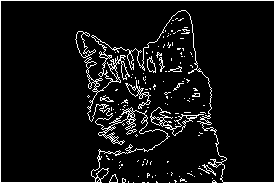

In [ ]:
import cv2
import numpy as np

my_photo = cv2.imread('/content/cat.jpg')
img_grey = cv2.cvtColor(my_photo,cv2.COLOR_BGR2GRAY)

#зададим порог
thresh = 180

#получим картинку, обрезанную порогом
ret,thresh_img = cv2.threshold(img_grey, thresh, 255, cv2.THRESH_BINARY)

#надем контуры
contours, hierarchy = cv2.findContours(thresh_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

#создадим пустую картинку
img_contours = np.zeros(my_photo.shape)

#отобразим контуры
cv2.drawContours(img_contours, contours, -1, (255,255,255), 1)
cv2_imshow(img_contours) # выводим итоговое изображение в окно

cv2.waitKey()
cv2.destroyAllWindows()

**Поп-арт**

1 - cv2.resize(image, (100, 100)) - сжимаем картинку, чтобы было похоже на мозаику

2 - interpolation=cv2.INTER_NEAREST - обратно растягиваем картинку, копируем цвет одного пикселя и воспроизводим его на весь квадрат

3 - cv2.convertScaleAbs с параметрами alpha=1.5 и beta=30 делает цвета более насыщенными

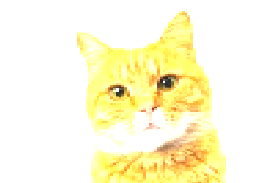

In [ ]:
import cv2
import numpy as np

# Загружаем изображение
image = cv2.imread('/content/cat.jpg')


# 1. Уменьшаем разрешение для "пикселизации"
small = cv2.resize(image, (100, 100), interpolation=cv2.INTER_LINEAR)
# 2. Возвращаем к исходному размеру с сохранением "квадратиков"
pop_art = cv2.resize(small, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)

# 3. Усиливаем цвета
pop_art = cv2.convertScaleAbs(pop_art, alpha=1.5, beta=30)

# Сохраняем результат
cv2_imshow(pop_art)


**Негатив**
Для каждого пикселя ищем обратный цвет (белый становится черным, желтый становится синим) - negative_image = 255 - image

Польза фильтра - обнаружение скрытых деталей, интересный эффект для фото

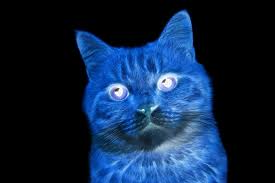

In [ ]:
import cv2
import numpy as np

# Загружаем изображение
image = cv2.imread('/content/cat.jpg')

# Просто инвертируем цвета (255 - текущее значение)
negative_image = 255 - image

# Сохраняем результат
cv2_imshow(negative_image)
